## 1. What is Deep Learning?
* Definition: Artificial Neural Networks learn complex patterns and hierarchical features automatically by using multiple hidden layers.
* Characteristics: Highly effective on massive and complex datasets but require large amounts of data and powerful hardware.

## 2. Machine Learning vs Deep Learning
* Definition: Machine Learning relies heavily on manual feature engineering and simpler algorithms, whereas Deep Learning automates feature extraction using deep neural networks.
* Characteristics: ML works well on smaller datasets with fast training times, while DL excels with big data and scales with increased data volume.

## 3. Feature Engineering
* Definition: The process of transforming raw data into meaningful features through human domain expertise so that traditional machine learning algorithms can understand them.
* Characteristic: Crucial for traditional ML success, but largely automated and bypassed in deep learning through representation learning.

## 4. Representation Learning
* Definition: A set of techniques that allows a system to automatically discover the representations needed for feature detection or classification directly from raw data.
* Characteristics: Eliminates the need for manual feature engineering; early layers capture simple edges and lines, while deeper layers capture complex, abstract concepts.

## 5. End-to-End Learning
* Definition: A learning paradigm where a single network is trained jointly from raw inputs directly to the final outputs without intermediate modular steps.
* Characteristics: Simplifies pipeline design by optimizing all components globally via a single loss function rather than training separate sub-modules independently.

## 6. Artificial Intelligence → Machine Learning → Deep Learning
* Definition: A hierarchical containment relationship where AI is the broad umbrella field, ML is a subset focused on data-driven learning, and DL is a specialized subset of ML using deep neural networks.
* Characteristics: Illustrates how deep learning forms the innermost, most advanced core driving modern artificial intelligence capabilities.

### Visualizing Representation Learning & Feature Extraction with CNN
In traditional machine learning, features are engineered manually. In Deep Learning, convolutional layers automatically learn hierarchical representations (such as edges, textures, and shapes) from raw pixel data.

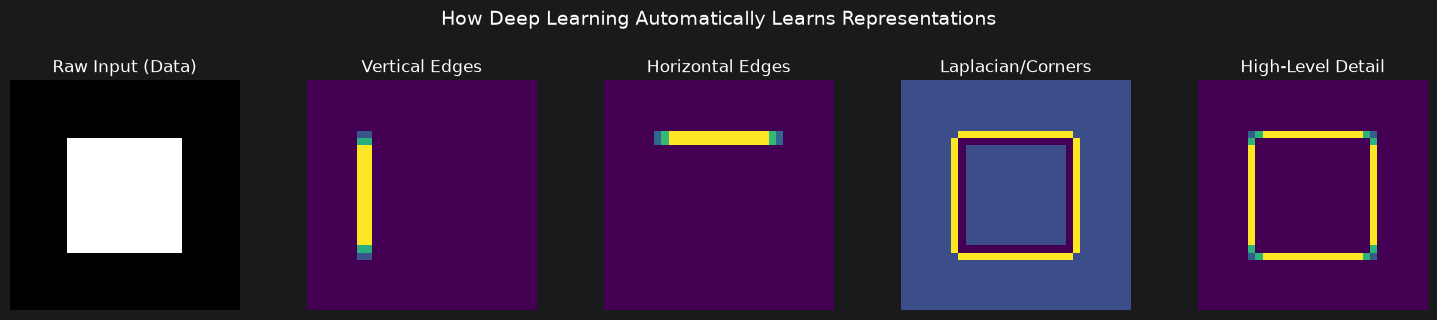

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a synthetic input image (e.g., a simple white square/line on a black background)
input_image = torch.zeros((1, 1, 32, 32))
input_image[:, :, 8:24, 8:24] = 1.0  # White square in the middle

# 2. Define a Convolutional Layer with 4 custom/random filters to detect different features (edges, corners)
conv_layer = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, stride=1, padding=1)

# Let's initialize specific weights to simulate edge/gradient detection filters
with torch.no_grad():
    # Filter 1: Vertical edge detector
    conv_layer.weight[0, 0] = torch.tensor([[-1., 0., 1.],
                                            [-1., 0., 1.],
                                            [-1., 0., 1.]])
    # Filter 2: Horizontal edge detector
    conv_layer.weight[1, 0] = torch.tensor([[-1., -1., -1.],
                                            [ 0.,  0.,  0.],
                                            [ 1.,  1.,  1.]])
    # Filter 3 & 4: Random filters for other representations
    conv_layer.weight[2, 0] = torch.tensor([[ 0.,  1.,  0.],
                                            [ 1., -4.,  1.],
                                            [ 0.,  1.,  0.]])
    conv_layer.weight[3, 0] = torch.tensor([[ 1.,  1.,  1.],
                                            [ 1., -8.,  1.],
                                            [ 1.,  1.,  1.]])

# 3. Pass the raw image through the convolutional layer (Representation Learning in action)
output_features = conv_layer(input_image)
output_features_relu = torch.relu(output_features) # Applying non-linearity

# 4. Plotting the original image vs. automated feature representations (Feature Maps)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Original Raw Input
axes[0].imshow(input_image[0, 0].detach().numpy(), cmap='gray')
axes[0].set_title("Raw Input (Data)")
axes[0].axis('off')

# Extracted Feature Maps (Filters 1 to 4)
titles = ["Vertical Edges", "Horizontal Edges", "Laplacian/Corners", "High-Level Detail"]
for i in range(4):
    ax = axes[i + 1]
    feature_map = output_features_relu[0, i].detach().numpy()
    ax.imshow(feature_map, cmap='viridis')
    ax.set_title(titles[i])
    ax.axis('off')

plt.suptitle("How Deep Learning Automatically Learns Representations", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()